In [1]:
# Firedrake coupled Saarelma–Connor solver tests
#
# Run from `tests/` (so `ROOT` points at the repo). Requires Firedrake +
# parent-class deps (OpenFUSIONToolkit, eqdsk/p-file inputs).

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import os

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
MHD_FP = INPUT_DIR / "g189650.02500"
KPROF_FP = INPUT_DIR / "p189650.02500"

# `solver-firedrake.py` has a hyphen — load by file path.
_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake",
    ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake


firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
# Shared solve kwargs (override per cell as needed).
initial_guess = "tanh"
ne_inner_bc = "neumann"
use_picard = False
SOLVE_KW = dict(
    x_res=20,
    fe_degree=2,
    use_picard=use_picard,
    picard_tol=1e-4,
    max_picard=100,
    relax=0.5,
    initial_guess=initial_guess,
    ne_inner_bc=ne_inner_bc,   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    linearize=False, # use full nonlinear form of equation
    verbose=False,
)

In [3]:
# Build the model once — the expensive flux-surface-averaging and equilibrium
# loading runs here only, not inside the loop.

# Scan size (each dimension has N points)
N = 5

# Scan parameters
alpha_crits = np.logspace(-1, 1, N)
# alpha_crits = np.array([0.1,10])
C_KBMs = np.logspace(-1, 1.5, N)
# C_KBMs = np.array([0.1])
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(15, 18, N)
ncx_x0_ratios = np.logspace(0.1,2,N)

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox

# Output data and files
success_fp = 'success_PTHmode.txt'
failure_fp = 'failure_PTHmode.txt'
error_messages_fp = 'error_messages_PTHmode.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, message\n")
ne_success_fp = 'scan_success_PTHmode'
verbose = False

base_model = saarelma_connor_firedrake(
        P_tot_e      = P_tot_e,
        alpha_crit   = round(float(alpha_crits[0]), 3),
        C_KBM        = round(float(C_KBMs[0]), 3),
        De_chie_etg  = round(float(De_chie_etgs[0]), 3),
        nFC_x0       = round(float(nFC_x0s[0]), 3),
        ncx_x0_ratio = round(float(ncx_x0_ratios[0]), 3),
        mhd_fp       = MHD_FP,
        kprof_fp     = KPROF_FP,
        verbose      = verbose,
        # psi_N_inner_boundary = 0.85, # set to None to use adaptive inner boundary method
)
print("Base model built.")

Base model built.


In [5]:
# Clear outputs from any previous scan (including appended failure logs).
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))
os.remove(success_fp)
os.remove(failure_fp)
os.remove(error_messages_fp)
with open(success_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
with open(failure_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
with open(error_messages_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, message\n")

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
# n_iter = 0
i=0
for alpha_crit in alpha_crits:
        j=0
        for C_KBM in C_KBMs:
                k=0
                for De_chie_etg in De_chie_etgs:
                        l=0
                        for nFC_x0 in nFC_x0s:
                                for ncx_x0_ratio in ncx_x0_ratios:
                                        ac = round(float(alpha_crit), 3)
                                        ck = round(float(C_KBM), 3)
                                        de = round(float(De_chie_etg), 3)
                                        nf = round(float(nFC_x0), 3)
                                        nc = round(float(ncx_x0_ratio),3)

                                        # Step 1: apply free params with adaptive thresholds active so
                                        # inner_boundary_limits can compute the outer limit correctly.
                                        base_model.update_free_params(
                                                alpha_crit    = ac,
                                                C_KBM         = ck,
                                                De_chie_etg   = de,
                                                nFC_x0        = nf,
                                                ncx_x0_ratio  = nc,
                                        )

                                        # psi_scan = np.linspace(0.87, 0.94, N)
                                        psi_scan = [0.85]

                                        m=0
                                        for psi_b in psi_scan:
                                                psi_val = round(float(psi_b), 4)
                                                try:
                                                        base_model.update_free_params(
                                                                alpha_crit            = ac,
                                                                C_KBM                 = ck,
                                                                De_chie_etg           = de,
                                                                nFC_x0                = nf,
                                                                psi_N_inner_boundary  = psi_val,
                                                                ncx_x0_ratio  = nc,
                                                        )
                                                        x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_firedrake(**SOLVE_KW)
                                                        sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
                                                except Exception as e: # run fails
                                                        with open(failure_fp, 'a') as f:
                                                                f.write(f"{ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}\n")
                                                        with open(error_messages_fp, 'a') as f:
                                                                f.write(f"{ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {e}\n")
                                                        m+=1
                                                else: # run works
                                                        with open(success_fp, 'a') as f:
                                                                f.write(f"{ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}\n")
                                                        np.save(f'{ne_success_fp}/ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}', sol, allow_pickle=True)
                                                        m+=1

                                                # n_iter += 1
                                                # if n_iter % 10 == 0: # RAM tracker
                                                #         gc.collect()
                                                #         print(f"  [{n_iter} iters] peak RAM ~ {_ram_mb():.0f} MB")
                                        l+=1
                                        # print(f"Completed {l} of {len(nFC_x0s)} nFC_x0s  [psi_N range: {psi_scan[0]:.3f}..{psi_scan[-1]:.3f}]") # progress logging
                        k+=1
                        # print(f"Completed {k} of {len(De_chie_etgs)} De_chie_etgs") # progress logging
                j+=1
                # print(f"Completed {j} of {len(C_KBMs)} C_KBMs") # progress logging
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits") # progress logging

Completed 1 of 5 alpha_crits
Completed 2 of 5 alpha_crits
Completed 3 of 5 alpha_crits
Completed 4 of 5 alpha_crits
Completed 5 of 5 alpha_crits


In [ ]:
from matplotlib.colors import Normalize
import csv
import re
from pathlib import Path
from scipy.interpolate import interp1d

scan_dir = Path(ne_success_fp)
pattern = re.compile(r"_([a-zA-Z]+)([\d.eE+-]+)")

# Read p-file density
def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                in_ne_block = 'ne(10^20/m^3)' in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20

psi_pfile, ne_pfile = read_pfile_ne(KPROF_FP)
peak_pfile = ne_pfile.max()
print(f"Experimental p-file peak n_e: {peak_pfile:.3e} m^-3")

# Build psi_N -> x mapping
ref = saarelma_connor_firedrake(
    P_tot_e=P_tot_e,
    alpha_crit=alpha_crits[0],
    C_KBM=C_KBMs[0],
    De_chie_etg=De_chie_etgs[0],
    nFC_x0=nFC_x0s[0],
    mhd_fp=MHD_FP,
    kprof_fp=KPROF_FP,
    verbose=False,
)
psi_to_x = interp1d(ref.psi_N_pres, ref.r_psi - ref.r_psi[-1],
                    kind='linear', bounds_error=False, fill_value='extrapolate')
x_to_psi = interp1d(ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
                    kind='linear', bounds_error=False, fill_value='extrapolate')

# Compute pedestal grid
psi_ped_grid = np.linspace(0.85, 1.0, 200)
x_ped_grid = psi_to_x(psi_ped_grid)
ne_pfile_on_ped = interp1d(psi_pfile, ne_pfile, kind='linear',
                           bounds_error=False, fill_value='extrapolate')(psi_ped_grid)
mean_ne_pfile = float(np.mean(ne_pfile_on_ped))

# Load success records
success_records = []
for npy_path in scan_dir.glob("ne_*.npy"):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    ne_pred_on_ped = interp1d(sol['x'], sol['y'], kind='linear',
                              bounds_error=False, fill_value='extrapolate')(x_ped_grid)
    l2 = np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2))
    success_records.append([
        params.get('a'), params.get('C'), params.get('D'),
        params.get('n'), params.get('nc'), params.get('b'), l2 / mean_ne_pfile,
    ])
success_arr_summary = np.array(success_records) if success_records else np.empty((0, 7))

# Load failure records
failure_records = []
try:
    with open(failure_fp, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            failure_records.append([float(x.strip()) for x in row])
except FileNotFoundError:
    pass
failure_arr_summary = np.array(failure_records) if failure_records else np.empty((0, 6))

# Panel labels and parameter values
panel_names = ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0', 'ncx_ratio', 'psi_inner']
panel_labels = [r'$\alpha_{\mathrm{crit}}$',
                r'$C_{\mathrm{KBM}}$',
                r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
                r'$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)',
                r'$n_{\mathrm{CX}}^{x_0}/n_{\mathrm{FC}}^{x_0}$',
                r'$\psi_{N,\,\mathrm{inner}}$']

param_values = [
    np.round(alpha_crits.astype(float), 3),
    np.round(C_KBMs.astype(float), 3),
    np.round(De_chie_etgs.astype(float), 3),
    np.round(nFC_x0s.astype(float), 3),
    np.round(ncx_x0_ratios.astype(float), 3),
    np.array([0.85]),
]

def _record_to_bins(record6):
    """Map one run to 6 scan-bin indices, or None if any parameter is off-grid."""
    bins = []
    for d in range(6):
        grid = param_values[d]
        val = float(record6[d])
        i = int(np.argmin(np.abs(grid - val)))
        if d == 5:  # psi_inner
            on_grid = np.isclose(grid[i], val, atol=5e-4)
        elif d == 4:  # ncx_x0_ratio
            on_grid = np.isclose(grid[i], val, rtol=1e-2)
        elif d == 3:  # nFC_x0
            on_grid = np.isclose(grid[i], val, rtol=1e-3)
        else:
            on_grid = np.isclose(grid[i], val, rtol=0, atol=1e-6)
        if not on_grid:
            return None
        bins.append(i)
    return tuple(bins)

# Build run outcomes
run_outcomes = {}
for record in success_arr_summary:
    bins6 = _record_to_bins(record[:6])
    if bins6 is None:
        continue
    run_outcomes[bins6] = {"success": True, "l2": float(record[6])}

for record in failure_arr_summary:
    bins6 = _record_to_bins(record[:6])
    if bins6 is None:
        continue
    run_outcomes.setdefault(bins6, {"success": False})

print(
    f"Unique 6D scan points: {len(run_outcomes)}; "
    f"{sum(1 for o in run_outcomes.values() if o['success'])} succeeded"
)

In [ ]:
# Plot best 5 and worst 5 n_e profiles depending on L2 distance from p-file
profile_runs = []
for npy_path in sorted(scan_dir.glob("ne_*.npy")):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    record6 = [params.get("a"), params.get("C"), params.get("D"),
               params.get("n"), params.get("nc"), params.get("b")]
    bins6 = _record_to_bins(record6)
    if bins6 is None:
        continue

    sol = np.load(npy_path, allow_pickle=True).item()
    x_sol = np.asarray(sol['x'], dtype=float)
    ne_sol = np.asarray(sol['y'], dtype=float)
    ne_pred_on_ped = interp1d(
        x_sol, ne_sol, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_ped_grid)
    l2_norm = float(np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2)) / mean_ne_pfile)

    label = (
        rf"$\alpha={params['a']:.3g}$, $C={params['C']:.3g}$, $D={params['D']:.3g}$, "
        rf"$n_{{FC,0}}={params['n']:.2e}$, $n_{{CX}}/n_{{FC}}={params['nc']:.3g}$, "
        rf"$\psi_N={params['b']:.4f}$, L2={l2_norm:.3f}"
    )
    entry = dict(l2=l2_norm, label=label, x=x_sol, ne=ne_sol, bins6=bins6)
    prev = next((r for r in profile_runs if r["bins6"] == bins6), None)
    if prev is None or l2_norm < prev["l2"]:
        if prev is not None:
            profile_runs.remove(prev)
        profile_runs.append(entry)

profile_runs.sort(key=lambda r: r["l2"])
n_show = min(5, len(profile_runs))
if n_show == 0:
    print("No on-grid successful scan profiles found — run the scan cell first.")
else:
    best = profile_runs[:n_show]
    worst = profile_runs[-n_show:][::-1]

    fig, (ax_best, ax_worst) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    for ax, subset, title in (
        (ax_best, best, f"Best {n_show} (lowest normalized L2)"),
        (ax_worst, worst, f"Worst {n_show} (highest normalized L2)"),
    ):
        x_lo = min(r["x"].min() for r in subset)
        x_hi = max(r["x"].max() for r in subset)
        x_plot = np.linspace(x_lo, x_hi, 250)
        psi_on_plot = x_to_psi(x_plot)
        ne_pfile_on_x = interp1d(
            psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
        )(psi_on_plot)
        ax.plot(
            x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
            label="p-file $n_e$",
        )

        for i, run in enumerate(subset):
            ax.plot(
                run["x"], run["ne"] / 1e19,
                color=plt.cm.tab10(i), lw=2.0, label=run["label"],
            )
        ax.axvline(0, color="k", ls=":", lw=0.8)
        ax.set_xlabel(r"$x$ (m)", fontsize=13)
        ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
        ax.set_title(title, fontsize=13)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=7, loc="lower left", framealpha=0.9)

    plt.savefig("compare_solvers_results_158040_03000/ne_"+ne_inner_bc+f"_{str(use_picard)}_"+initial_guess+".png", dpi=300)
    plt.show()

In [ ]:
# Plot all profiles on a color gradient (sorted by L2)
profile_runs = []
for npy_path in sorted(scan_dir.glob("ne_*.npy")):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    record6 = [params.get("a"), params.get("C"), params.get("D"),
               params.get("n"), params.get("nc"), params.get("b")]
    bins6 = _record_to_bins(record6)
    if bins6 is None:
        continue

    sol = np.load(npy_path, allow_pickle=True).item()
    x_sol = np.asarray(sol['x'], dtype=float)
    ne_sol = np.asarray(sol['y'], dtype=float)
    ne_pred_on_ped = interp1d(
        x_sol, ne_sol, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_ped_grid)
    l2_norm = float(np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2)) / mean_ne_pfile)

    label = (
        rf"$\alpha={params['a']:.3g}$, $C={params['C']:.3g}$, $D={params['D']:.3g}$, "
        rf"$n_{{FC,0}}={params['n']:.2e}$, $n_{{CX}}/n_{{FC}}={params['nc']:.3g}$, "
        rf"$\psi_N={params['b']:.4f}$, L2={l2_norm:.3f}"
    )
    entry = dict(l2=l2_norm, label=label, x=x_sol, ne=ne_sol, bins6=bins6)
    prev = next((r for r in profile_runs if r["bins6"] == bins6), None)
    if prev is None or l2_norm < prev["l2"]:
        if prev is not None:
            profile_runs.remove(prev)
        profile_runs.append(entry)

profile_runs.sort(key=lambda r: r["l2"]) # best to worst profiles in L2 order
n_show = len(profile_runs)
if n_show == 0:
    print("No on-grid successful scan profiles found — run the scan cell first.")
else:
    fig, ax = plt.subplots()
    x_lo = min(r["x"].min() for r in profile_runs)
    x_hi = max(r["x"].max() for r in profile_runs)
    x_plot = np.linspace(x_lo, x_hi, 250)
    psi_on_plot = x_to_psi(x_plot)
    ne_pfile_on_x = interp1d(
        psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_on_plot)
    ax.plot(
        x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
        label="p-file $n_e$",
    )

    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.cm import ScalarMappable

    l2_values = [run["l2"] for run in profile_runs]
    vmin = min(l2_values)
    vmax = max(l2_values)

    num_runs = len(profile_runs)
    cmap = LinearSegmentedColormap.from_list('custom', ['green', 'yellow', 'red'])
    for i, run in enumerate(profile_runs):
        fraction = i / (num_runs - 1) if num_runs > 1 else 0.5
        ax.plot(
            run["x"], run["ne"] / 1e19,
            color=cmap(fraction), lw=2.0, label=run["label"], alpha=0.5
        )
    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=13)
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=12)
    # Create a ScalarMappable for the colorbar
    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # This is required for the colorbar to render correctly

    # Add the colorbar to the figure, attached to your specific axes
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("L2 (green=best, red=worst)") # Label the colorbar

In [ ]:
# 5-panel plot: each panel varies one free parameter; the other four are held
# fixed at the index chosen below for that parameter's scan array.
# Requires the scan cell and the data-loading cell above to have been run.

# --- fix indices (one per scan array) ---------------------------------------
fix_idx_alpha_crit   = 0   # alpha_crits[fix_idx_alpha_crit]
fix_idx_C_KBM        = 2   # C_KBMs[fix_idx_C_KBM]
fix_idx_De_chie_etg  = 2   # De_chie_etgs[fix_idx_De_chie_etg]
fix_idx_nFC_x0       = 2   # nFC_x0s[fix_idx_nFC_x0]
fix_idx_ncx_x0_ratio = 2   # ncx_x0_ratios[fix_idx_ncx_x0_ratio]

fix_indices = [
    fix_idx_alpha_crit,
    fix_idx_C_KBM,
    fix_idx_De_chie_etg,
    fix_idx_nFC_x0,
    fix_idx_ncx_x0_ratio,
]

free_param_names = ["alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio"]
param_arrays = [alpha_crits, C_KBMs, De_chie_etgs, nFC_x0s, ncx_x0_ratios]
param_keys = ["a", "C", "D", "n", "nc"]
panel_labels = [
    r"$\alpha_{\mathrm{crit}}$",
    r"$C_{\mathrm{KBM}}$",
    r"$D_{e}\chi_{e}^{\mathrm{ETG}}$",
    r"$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)",
    r"$n_{\mathrm{CX}}^{x_0}/n_{\mathrm{FC}}^{x_0}$",
]


def _params_for_slice(vary_dim, vary_idx): # vary_dim is the index of the free parameter that is being varied. vary_idx is the index in the array of the free parameter being varied.
    """Build filename-key dict for one (varied dim, index) combination."""
    out = {}
    for d, key in enumerate(param_keys): # param_keys is a list of the free parameter names.
        # The next line is contructing slices, so it finds 
        idx = vary_idx if d == vary_dim else fix_indices[d] # fix_indices is a list of the indices that are used in the free parameter arrays for which value to fix for slices. d=vary_dim (free parameter being varied)
        # idx = vary_idx run if you are in the case where you're scanning over the free parameter being varied.
        out[key] = round(float(param_arrays[d][idx]), 3) # param_arrays is a list of arrays of all the free parameter values. param_arrays[d] selects which free parameter is being varied. 
        # param_arrays[d][idx] selects the value of the free parameter being varied and which value of the free parameter is being used.
        # key = a, C, D, n, nc and d=0,1,2,3,4
    out["b"] = round(float(param_values[5][0]), 4)  # psi_N_inner from cell above
    return out # out[key] = value of free parameter specified by vary_dim and vary_idx. if you are in the fixed free parameter case, you only output the fixed free parameter value.


def _find_profile(vary_dim, vary_idx): # this runs once for each value scanned of the free parameter specified by vary_dim.
    target = _params_for_slice(vary_dim, vary_idx) # target is the parameter combination with all fixed free parameters and the free parameter being varied. it only outputs one parameter combination at a time
    record6 = [target[k] for k in param_keys] + [target["b"]] # list of parameter names in target (should be the same for all)
    bins6 = _record_to_bins(record6) # finds index of each of the free parameter values in target with respect to each free parameter's array
    if bins6 is None:
        return None

    for npy_path in scan_dir.glob("ne_*.npy"): # loop over every file with a ne_ prefix in scan_dir
        pairs = pattern.findall(npy_path.stem) # extracts letter/number pairs from the filename. Example: ne_a0.1_C0.316_... → [('a', '0.1'), ('C', '0.316'), ...].
        params = {letter: float(num) for letter, num in pairs} # turn letter/num pairs into dictionaries
        cand = [params.get(k) for k in param_keys] + [params.get("b")] # same as record6 for target
        if _record_to_bins(cand) == bins6: # check if this is the target parameter combination
            sol = np.load(npy_path, allow_pickle=True).item()
            return dict(
                x=np.asarray(sol["x"], dtype=float),
                ne=np.asarray(sol["y"], dtype=float),
                params=target,
                vary_val=param_arrays[vary_dim][vary_idx],
            )
    return None


def _load_profiles_for_vary_dim(vary_dim): # runs once for each free parameter being varied.
    profiles = []
    for vary_idx in range(len(param_arrays[vary_dim])): # param_arrays is a list of arrays of all the free parameter values. param_arrays[vary_dim] selects which free parameter is being varied. So this loop runs fully per free parameter
        # this for loop runs once for each value scanned of the free parameter specified by vary_dim.
        prof = _find_profile(vary_dim, vary_idx) # vary_idx is the index in the array of the free parameter being varied. vary_dim is the index of the free parameter that is being varied.
        if prof is not None:
            profiles.append(prof)
    return profiles


# --- load slices and report fixed values ------------------------------------
slices_5d = [_load_profiles_for_vary_dim(d) for d in range(5)] # d=0,1,2,3,4
# the line above gives each sol profile for the varied free parameter for each d=0,1,2,3,4 IN THAT ORDER - d=0, all values; d=1, all values; etc.
# each parameter d gets its own index in this slices_5d list. In each index, there is a list of sol profiles for the varied free parameter for each value scanned of that free parameter.

print("=== 5-panel configuration ===")
for d, name in enumerate(free_param_names): # just a print statement
    fixed = param_arrays[d][fix_indices[d]]
    print(f"  {panel_labels[d]} fixed at index {fix_indices[d]} -> {fixed:g}")

if not any(slices_5d):
    print("No matching scan profiles found — run the scan cell first.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    axes = axes.ravel() # flattens the 2x3 array into a 1x6 array

    for d, ax in enumerate(axes[:5]): # loop over each subplot
        profiles = slices_5d[d]
        if not profiles:
            # ax.set_title(f"{panel_labels[d]} (no data)")
            ax.set_visible(False)
            continue

        x_lo = min(p["x"].min() for p in profiles)
        x_hi = max(p["x"].max() for p in profiles)
        x_plot = np.linspace(x_lo, x_hi, 250)
        psi_on_plot = x_to_psi(x_plot)
        ne_pfile_on_x = interp1d(
            psi_pfile, ne_pfile, kind="linear",
            bounds_error=False, fill_value="extrapolate",
        )(psi_on_plot)
        ax.plot(
            x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=5, lw=0.9,
            label="p-file $n_e$",
        )

        cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(profiles)))
        for i, prof in enumerate(profiles): # each profile in the parameter of interest
            
            # Setup legend
            print('prof: ',prof)
            val = prof["vary_val"] # vary_val is the current value of the free parameter being varied.
            if d in (3,):  # only for formatting nFC_x0 into scientific notation
                leg = rf"${val:.2e}$"
            else:
                leg = rf"${val:.3g}$"
            
            ax.plot(
                prof["x"], prof["ne"] / 1e19,
                color=cmap[i], lw=2.0, label=leg,
            )

        ax.axvline(0, color="k", ls=":", lw=0.8)
        ax.set_xlabel(r"$x$ (m)", fontsize=12)
        ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=12)
        fixed_parts = [
            rf"{panel_labels[j]}={param_arrays[j][fix_indices[j]]:.3g}"
            for j in range(5) if j != d
        ]
        ax.set_title(
            rf"Vary {panel_labels[d]};  fixed: {', '.join(fixed_parts)}",
            fontsize=11,
        )
        ax.grid(True, alpha=0.3)
        ax.legend(title=panel_labels[d], fontsize=8, title_fontsize=9, loc="best")

    axes[5].set_visible(False)
    # plt.savefig(
    #     f"compare_solvers_results_158040_03000/fparam_scan_panels_"
    #     f"{ne_inner_bc}_{use_picard}_{initial_guess}.png",
    #     dpi=300,
    # )
    plt.show()

In [ ]:
for i in range(len(slices_5d[0])):
    print(slices_5d[0][i]['params'])

In [ ]:
# Scan ncx_x0_ratio
ncx_x0_ratios = np.logspace(-2, 2, 10)


# Clear outputs from any previous scan (including appended failure logs).
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))
os.remove(success_fp)
os.remove(failure_fp)
os.remove(error_messages_fp)
with open(success_fp, "w") as f:
    f.write("ncx_x0_ratio\n")
with open(failure_fp, "w") as f:
    f.write("ncx_x0_ratio\n")
with open(error_messages_fp, "w") as f:
    f.write("ncx_x0_ratio, message\n")

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
ac = alpha_crits[-1]
ck = C_KBMs[0]
de = De_chie_etgs[0]
nf = nFC_x0s[0]
psi_val = 0.85
i=0
for ncx_x0_ratio in ncx_x0_ratios:
        try:
                base_model.update_free_params(
                        alpha_crit            = ac,
                        C_KBM                 = ck,
                        De_chie_etg           = de,
                        nFC_x0                = nf,
                        psi_N_inner_boundary  = psi_val,
                        ncx_x0_ratio          = ncx_x0_ratio,
                )
                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_firedrake(**SOLVE_KW)
                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
        except Exception as e: # run fails
                with open(failure_fp, 'a') as f:
                        f.write(f"{ncx_x0_ratio}\n")
                with open(error_messages_fp, 'a') as f:
                        f.write(f"{ncx_x0_ratio}, {e}\n")
        else: # run works
                with open(success_fp, 'a') as f:
                        f.write(f"{ncx_x0_ratio}\n")
                np.save(f'{ne_success_fp}/ne_ncx_x0_ratio{ncx_x0_ratio}', sol, allow_pickle=True)
        i+=1

In [ ]:
# Plot n_e profiles from ncx_x0_ratio scan (standalone — run from tests/firedrake_solver/).
import importlib.util
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
MHD_FP = INPUT_DIR / "g189650.02500"
KPROF_FP = INPUT_DIR / "p189650.02500"
ne_success_fp = "scan_success_PTHmode"

_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake", ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake


def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20


psi_pfile, ne_pfile = read_pfile_ne(KPROF_FP)

# Match fixed parameters used in the ncx_x0_ratio scan cell.
N = 5
P_tot_e = 5e6
alpha_crits = np.logspace(-2, 1.5, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(15.5, 18.5, N)
psi_scan = np.linspace(0.85, 0.94, N)
ac, ck, de, nf, psi_val = (
    alpha_crits[-1], C_KBMs[0], De_chie_etgs[0], nFC_x0s[0], psi_scan[0],
)

ref = saarelma_connor_firedrake(
    P_tot_e=P_tot_e,
    alpha_crit=round(float(ac), 3),
    C_KBM=round(float(ck), 3),
    De_chie_etg=round(float(de), 3),
    nFC_x0=round(float(nFC_x0s[0]), 3),
    mhd_fp=MHD_FP,
    kprof_fp=KPROF_FP,
    verbose=False,
)
x_to_psi = interp1d(
    ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
    kind="linear", bounds_error=False, fill_value="extrapolate",
)

ncx_scan_dir = Path(ne_success_fp)
ncx_pattern = re.compile(r"ne_ncx_x0_ratio([\d.eE+-]+)")

ncx_runs = []
for npy_path in sorted(ncx_scan_dir.glob("ne_ncx_x0_ratio*.npy")):
    m = ncx_pattern.match(npy_path.stem)
    if not m:
        continue
    ratio = float(m.group(1))
    sol = np.load(npy_path, allow_pickle=True).item()
    ncx_runs.append({
        "ratio": ratio,
        "x": np.asarray(sol["x"], dtype=float),
        "ne": np.asarray(sol["y"], dtype=float),
    })
ncx_runs.sort(key=lambda r: r["ratio"])

if not ncx_runs:
    print("No ncx_x0_ratio scan profiles found — run the scan cell first.")
else:
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    x_lo = min(r["x"].min() for r in ncx_runs)
    x_hi = max(r["x"].max() for r in ncx_runs)
    x_plot = np.linspace(x_lo, x_hi, 250)
    psi_on_plot = x_to_psi(x_plot)
    ne_pfile_on_x = interp1d(
        psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_on_plot)
    ax.plot(
        x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
        label="p-file $n_e$", zorder=10,
    )

    cmap = plt.get_cmap("viridis")
    n_runs = len(ncx_runs)
    for k, run in enumerate(ncx_runs):
        color = cmap(k / (n_runs - 1)) if n_runs > 1 else cmap(0.5)
        ax.plot(
            run["x"], run["ne"] / 1e19, lw=2.0, color=color,
            label=rf"$n_{{\mathrm{{CX}}}}^{{x_0}}/n_{{\mathrm{{FC}}}}^{{x_0}}$ = {run['ratio']:.4g}",
        )

    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=13)
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
    ax.set_title(
        rf"$n_e$ vs. $n_{{\mathrm{{CX}}}}^{{x_0}}/n_{{\mathrm{{FC}}}}^{{x_0}}$ "
        rf"($\alpha={ac}$, $C={ck}$, $D={de}$, $n_{{\mathrm{{FC,0}}}}={nf:.2e}$, $\psi_N={psi_val}$)",
        fontsize=12,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="best", framealpha=0.9)
    plt.show()


Scan the inner boundary condition to test stand-alone ability

Fixed free parameters:
  alpha_crit=0.1, C_KBM=1.778, De_chie_etg=1.778, nFC_x0=3.162e+16, ncx_x0_ratio=11.22
  psi_N_inner=0.85, x_inner=-0.0526 m
  p-file ne(x_inner) = 7.062e+19 m^-3
  scanning ne_inner from 3.531e+19 to 1.059e+20 m^-3
  ok  ne_inner=3.531e+19 m^-3  (50.0% of p-file)
  ok  ne_inner=4.316e+19 m^-3  (61.1% of p-file)
  ok  ne_inner=5.100e+19 m^-3  (72.2% of p-file)
  ok  ne_inner=5.885e+19 m^-3  (83.3% of p-file)
  ok  ne_inner=6.670e+19 m^-3  (94.4% of p-file)
  ok  ne_inner=7.454e+19 m^-3  (105.6% of p-file)
  ok  ne_inner=8.239e+19 m^-3  (116.7% of p-file)
  ok  ne_inner=9.024e+19 m^-3  (127.8% of p-file)
  ok  ne_inner=9.808e+19 m^-3  (138.9% of p-file)
  ok  ne_inner=1.059e+20 m^-3  (150.0% of p-file)


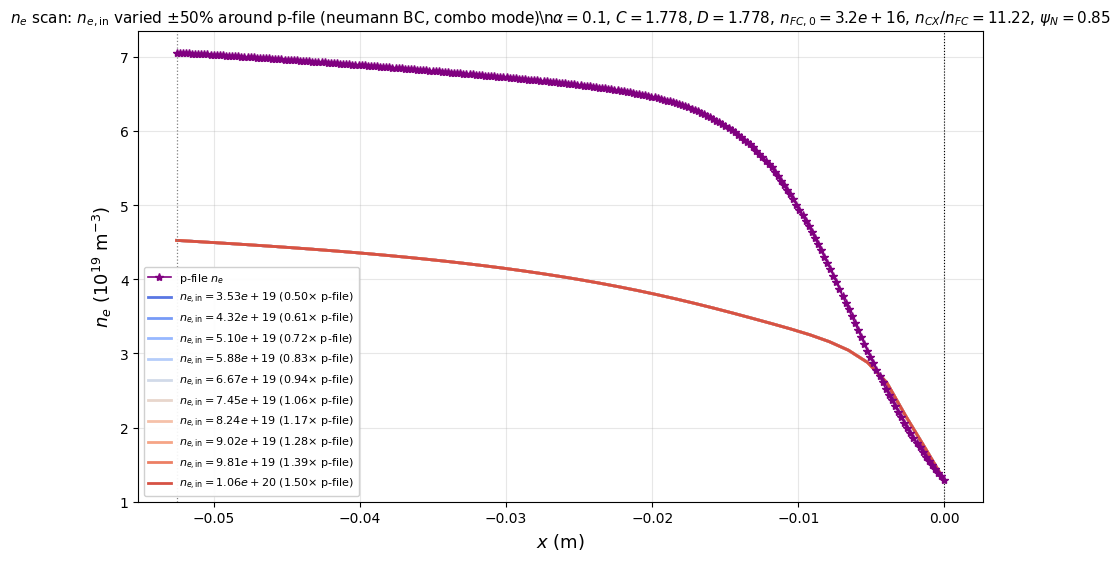

In [7]:
# Scan user-set n_e(x_inner) around the p-file value (bc_origin="p-file user combo").
# Requires cells 0–2 (imports, SOLVE_KW, base_model + scan arrays).
from scipy.interpolate import interp1d

scan_range = 0.5  # scan ±20% around the p-file value at x_inner
N_ne_inner = 10     # number of ne_inner scan points
psi_N_inner = 0.85 # inner boundary (match main fparam scan)

# --- fix indices (same convention as 5-panel plot) ---------------------------
fix_idx_alpha_crit   = 0
fix_idx_C_KBM        = 2
fix_idx_De_chie_etg  = 2
fix_idx_nFC_x0       = 2
fix_idx_ncx_x0_ratio = 2

ac = round(float(alpha_crits[fix_idx_alpha_crit]), 3)
ck = round(float(C_KBMs[fix_idx_C_KBM]), 3)
de = round(float(De_chie_etgs[fix_idx_De_chie_etg]), 3)
nf = round(float(nFC_x0s[fix_idx_nFC_x0]), 3)
nc = round(float(ncx_x0_ratios[fix_idx_ncx_x0_ratio]), 3)

base_model.update_free_params(
    alpha_crit=ac,
    C_KBM=ck,
    De_chie_etg=de,
    nFC_x0=nf,
    ncx_x0_ratio=nc,
    psi_N_inner_boundary=psi_N_inner,
)

# Reference inner BC values from the p-file (same as bc_origin="p-file").
base_model.x_inner = float(
    np.interp(psi_N_inner, base_model.psi_N_pres, base_model.x_init) # will need to run other cells to get x_init from an initial build of the solver grids
)
dne_dx_pres = np.gradient(base_model.n_e_pres, base_model.x_init)
ne_inner_pfile = float(
    np.interp(base_model.x_inner, base_model.x_init, base_model.n_e_pres)
)
dne_dx_inner_pfile = float(
    np.interp(base_model.x_inner, base_model.x_init, dne_dx_pres)
)

ne_inner_scan = np.linspace(
    ne_inner_pfile * (1.0 - scan_range),
    ne_inner_pfile * (1.0 + scan_range),
    N_ne_inner,
)

print("Fixed free parameters:")
print(f"  alpha_crit={ac}, C_KBM={ck}, De_chie_etg={de}, nFC_x0={nf:.3e}, ncx_x0_ratio={nc}")
print(f"  psi_N_inner={psi_N_inner}, x_inner={base_model.x_inner:.4f} m")
print(f"  p-file ne(x_inner) = {ne_inner_pfile:.3e} m^-3")
print(f"  scanning ne_inner from {ne_inner_scan[0]:.3e} to {ne_inner_scan[-1]:.3e} m^-3")

# --- run scan ----------------------------------------------------------------
ne_inner_runs = []
for ne_in in ne_inner_scan:
    solve_kw = dict(
        SOLVE_KW,
        bc_origin="p-file user combo",
        ne_inner=float(ne_in),
    )
    # Dirichlet combo mode still needs dne_dx_inner passed explicitly (solver-firedrake logic).
    if ne_inner_bc == "dirichlet":
        solve_kw["dne_dx_inner"] = dne_dx_inner_pfile

    try:
        x_sol, ne_sol, _, _ = base_model.solve_firedrake(**solve_kw)
        ne_inner_runs.append(
            dict(
                ne_inner=float(ne_in),
                frac=float(ne_in / ne_inner_pfile),
                x=np.asarray(x_sol, dtype=float),
                ne=np.asarray(ne_sol, dtype=float),
                success=True,
            )
        )
        print(f"  ok  ne_inner={ne_in:.3e} m^-3  ({100*ne_in/ne_inner_pfile:.1f}% of p-file)")
    except Exception as e:
        ne_inner_runs.append(dict(ne_inner=float(ne_in), success=False, error=str(e)))
        print(f"  FAIL ne_inner={ne_in:.3e} m^-3: {e}")

# --- plot --------------------------------------------------------------------
if not any(r.get("success") for r in ne_inner_runs):
    print("No successful solves — check parameters / scan range.")
else:
    ok_runs = [r for r in ne_inner_runs if r.get("success")]
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

    x_lo = min(r["x"].min() for r in ok_runs)
    x_hi = max(r["x"].max() for r in ok_runs)
    x_plot = np.linspace(x_lo, x_hi, 250)
    ne_pfile_on_x = interp1d(
        base_model.x_init, base_model.n_e_pres,
        kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_plot)
    ax.plot(
        x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=1.2,
        label="p-file $n_e$",
        zorder=10,
    )

    cmap = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(ok_runs)))
    for i, run in enumerate(ok_runs):
        label = rf"$n_{{e,\mathrm{{in}}}}={run['ne_inner']:.2e}$ ({run['frac']:.2f}$\times$ p-file)"
        if np.isclose(run["ne_inner"], ne_inner_pfile, rtol=1e-3):
            ax.plot(
                run["x"], run["ne"] / 1e19,
                color="k", lw=2.8, ls="-", label=label + " [p-file value]",
                zorder=5,
            )
        else:
            ax.plot(
                run["x"], run["ne"] / 1e19,
                color=cmap[i], lw=2.0, label=label,
            )

    ax.axvline(base_model.x_inner, color="gray", ls=":", lw=0.9)
    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=13)
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
    ax.set_title(
        rf"$n_e$ scan: $n_{{e,\mathrm{{in}}}}$ varied $\pm${scan_range*100:.0f}% around p-file "
        rf"({ne_inner_bc} BC, combo mode)\n"
        rf"$\alpha={ac}$, $C={ck}$, $D={de}$, $n_{{FC,0}}={nf:.1e}$, $n_{{CX}}/n_{{FC}}={nc}$, "
        rf"$\psi_N={psi_N_inner}$",
        fontsize=11,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best", framealpha=0.92)
    plt.show()
